# Importing the Dog vs Cat Dataset from Kaggle

In [8]:
# Configuring the path for kaggle.json file
!kaggle competitions download -c dogs-vs-cats



  0%|          | 0.00/812M [00:00<?, ?B/s]
  6%|▋         | 52.0M/812M [00:00<00:02, 267MB/s]
 15%|█▌        | 122M/812M [00:00<00:01, 458MB/s] 
 23%|██▎       | 185M/812M [00:00<00:01, 527MB/s]
 31%|███       | 249M/812M [00:00<00:01, 576MB/s]
 38%|███▊      | 312M/812M [00:00<00:00, 601MB/s]
 46%|████▋     | 376M/812M [00:00<00:01, 400MB/s]
 52%|█████▏    | 424M/812M [00:04<00:09, 42.1MB/s]
 58%|█████▊    | 475M/812M [00:05<00:06, 57.4MB/s]
 66%|██████▌   | 537M/812M [00:05<00:03, 82.6MB/s]
 72%|███████▏  | 587M/812M [00:05<00:02, 103MB/s] 
 77%|███████▋  | 627M/812M [00:08<00:04, 41.3MB/s]
 84%|████████▍ | 684M/812M [00:08<00:02, 59.5MB/s]
 93%|█████████▎| 754M/812M [00:08<00:00, 89.7MB/s]
100%|██████████| 812M/812M [00:08<00:00, 99.0MB/s]


In [1]:
# Extracting the dataset

from zipfile import ZipFile

dataset = 'dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Data Extraction completed")

Data Extraction completed


In [2]:
# Extracting the train zip file

from zipfile import ZipFile

dataset = 'train.zip'
with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Train data extraction compelted")

Train data extraction compelted


In [3]:
# Extracting the Test Zip File

from zipfile import ZipFile

dataset = 'test1.zip'
with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Test File extracted")

Test File extracted


In [4]:
# Printing names of images
import os

file_names = os.listdir('train/')
print(file_names)

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10006.jpg', 'cat.10007.jpg', 'cat.10008.jpg', 'cat.10009.jpg', 'cat.1001.jpg', 'cat.10010.jpg', 'cat.10011.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10014.jpg', 'cat.10015.jpg', 'cat.10016.jpg', 'cat.10017.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.1002.jpg', 'cat.10020.jpg', 'cat.10021.jpg', 'cat.10022.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10025.jpg', 'cat.10026.jpg', 'cat.10027.jpg', 'cat.10028.jpg', 'cat.10029.jpg', 'cat.1003.jpg', 'cat.10030.jpg', 'cat.10031.jpg', 'cat.10032.jpg', 'cat.10033.jpg', 'cat.10034.jpg', 'cat.10035.jpg', 'cat.10036.jpg', 'cat.10037.jpg', 'cat.10038.jpg', 'cat.10039.jpg', 'cat.1004.jpg', 'cat.10040.jpg', 'cat.10041.jpg', 'cat.10042.jpg', 'cat.10043.jpg', 'cat.10044.jpg', 'cat.10045.jpg', 'cat.10046.jpg', 'cat.10047.jpg', 'cat.10048.jpg', 'cat.10049.jpg', 'cat.1005.jpg'

# Importing Dependencies

In [5]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

# Image of Dogs and Cats

<function matplotlib.pyplot.show(close=None, block=None)>

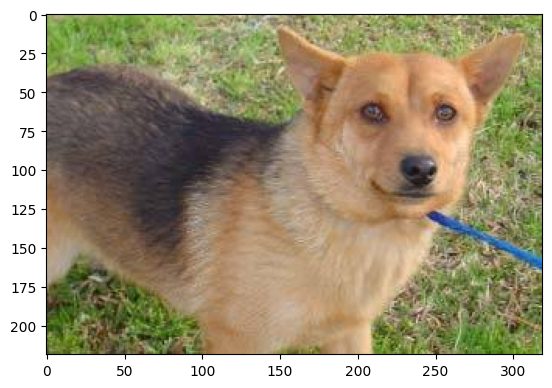

In [6]:
# Viewing the Dog image

img = mpimg.imread('train/dog.6053.jpg')
impplt = plt.imshow(img)
plt.show

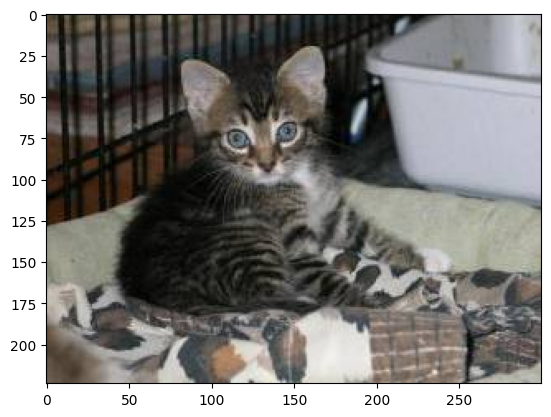

In [9]:
# Viewing the Cat image

img = mpimg.imread('train/cat.12.jpg')
implt = plt.imshow(img)
plt.show()

In [12]:
file_names = os.listdir('train/')

for i in range(5):
    name = file_names[i]
    print(name)
    print(name[0:3])

cat.0.jpg
cat
cat.1.jpg
cat
cat.10.jpg
cat
cat.100.jpg
cat
cat.1000.jpg
cat


In [13]:
file_names = os.listdir('train/')
dog_count = 0
cat_count = 0


for img in file_names:
    name = img[0:3]

    if name =='dog':
        dog_count+=1
    else:
        cat_count+=1

print('Number of dog images:', dog_count)
print('Number of Cat Images:', cat_count)

Number of dog images: 12500
Number of Cat Images: 12500


# Resizing all Images

In [18]:
# Creating a directory for resizeed images

# if not os.path.exists('Image Resized'):

#    os.mkdir('Image Resized')

#orginal_folder = 'train/'
#resized_folder = 'Image Resized/'

#for i in range(25000):
#    file_name = os.listdir(orginal_folder)[i]
#    img_path = orginal_folder+file_name


#    img = Image.open(img_path)
#   img = img.resize((224,224))
#    img = img.convert('RGB')

#    new_img_path = resized_folder+file_name
#    img.save(new_img_path)

For faster process

In [22]:
import os
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

original_folder = 'train/'
resized_folder = 'Image Resized/'
os.makedirs(resized_folder, exist_ok=True)

def process_image(file_name):
    try:
        img_path = os.path.join(original_folder, file_name)
        new_img_path = os.path.join(resized_folder, file_name)

        img = cv2.imread(img_path)
        if img is None:
            return
        img = cv2.resize(img, (224, 224))
        cv2.imwrite(new_img_path, img)
    except Exception as e:
        print(f"Error with {file_name}: {e}")

if __name__ == "__main__":
    files = [entry.name for entry in os.scandir(original_folder) if entry.is_file()]

    with ThreadPoolExecutor(max_workers=8) as executor:
        list(tqdm(executor.map(process_image, files), total=len(files)))


100%|██████████| 25000/25000 [01:06<00:00, 374.52it/s] 


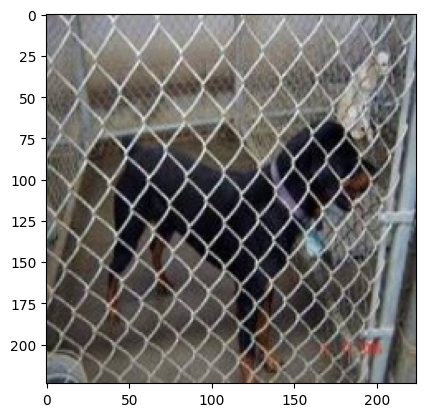

In [28]:
# Viewing resized image

img = mpimg.imread('Image Resized/dog.2980.jpg')
imgplt = plt.imshow(img)
plt.show()

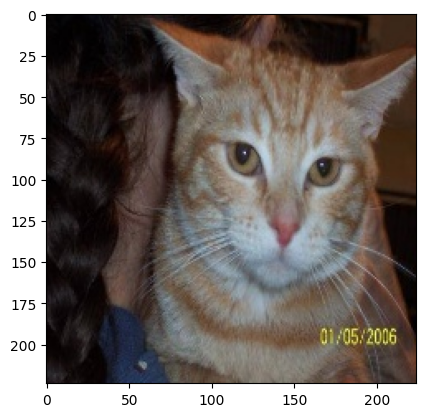

In [32]:
# Viewing cat image

img = mpimg.imread('Image Resized/cat.5879.jpg')
imgplt = plt.imshow(img)
plt.show()

# Creating Labels for resized images of dog and cats

Cat --> 0

Dog --> 1

In [46]:
# Creating a for loop for assign lables

filenames = os.listdir('Image Resized/')

labels = []

for i in range(25000):
    file_name = filenames[i]
    label_str = file_name[0:3]

    if label_str =='dog':
        labels.append(1)

    else:
        labels.append(0)

In [53]:
print(filenames[0:5])
print(len(filenames))

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg']
25000


In [55]:
print(labels[0:5])
print(len(labels))

[0, 0, 0, 0, 0]
25000


In [54]:
# Counting the no of images in cats and dogs 

values, counts = np.unique(labels, return_counts = True)
print(values)
print(counts)

[0 1]
[12500 12500]
